# Preprocessing and Grouping

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('phivolcs_earthquake_oct.csv')

df.head()

,Date_Time_PH,Latitude,Longitude,Depth_In_Km,Magnitude,Location,Specific_Location,General_Location,date
0,2025-12-30 19:10:00,11.96,122.29,10.0,4.2,020 km N 9° E of Tangalan (Aklan),Tangalan,Aklan,2025-12-30 19:10:00
1,2025-12-30 19:02:00,9.69,126.24,28.0,1.4,014 km S 40° E of General Luna (Surigao Del No...,General Luna,Surigao Del Norte,2025-12-30 19:02:00
2,2025-12-30 17:58:00,17.84,120.54,31.0,2.2,010 km S 73° E of Sinait (Ilocos Sur),Sinait,Ilocos Sur,2025-12-30 17:58:00
3,2025-12-30 16:49:00,10.00,126.10,32.0,2.3,003 km S 42° E of Burgos (Surigao Del Norte),Burgos,Surigao Del Norte,2025-12-30 16:49:00
4,2025-12-30 15:27:00,6.40,126.75,14.0,3.6,079 km S 25° E of Tarragona (Davao Oriental),Tarragona,Davao Oriental,2025-12-30 15:27:00


In [3]:
print(df.shape)

(117599, 9)


In [4]:
# CLEAN NUMERIC COLUMNS

# Replace hyphens with NaN
df = df.replace('-', np.nan)

# Convert numeric columns properly
numeric_cols = ['Latitude', 'Longitude', 'Depth_In_Km', 'Magnitude']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop rows that still contain NaN in these fields
df = df.dropna(subset=numeric_cols)

print(df.shape)

(117556, 9)


### Completeness threshold for magnitude

In [5]:
# completeness threshold for magnitude
df = df[df['Magnitude'] >= 1.9]
print(df.shape)

(98519, 9)


In [7]:
# Parse date format (e.g. 2025-12-09 02:50:00)
df['date'] = pd.to_datetime(df['date'])

# Copy depth & magnitude
df['depth'] = df['Depth_In_Km'].values
df['mag'] = df['Magnitude'].values

# Text features
# df['region'] = df['General_Location']

lat = df['Latitude'].values
lon = df['Longitude'].values

def hypocenter_to_xyz(lat, lon, depth):
    lat = np.radians(lat)
    lon = np.radians(lon)
    R = 6371  # Earth radius (km)

    r = R - depth  # move inward

    x = r * np.cos(lat) * np.cos(lon)
    y = r * np.cos(lat) * np.sin(lon)
    z = r * np.sin(lat)

    return x, y, z

# Explicitly ensure 'Depth_In_Km' is numeric and has no NaNs
df['Depth_In_Km'] = pd.to_numeric(df['Depth_In_Km'], errors='coerce')
df.dropna(subset=['Depth_In_Km'], inplace=True)

x, y, z = hypocenter_to_xyz(df['Latitude'], df['Longitude'], df['Depth_In_Km'])

df['x'] = x
df['y'] = y
df['z'] = z

df.head()

,Date_Time_PH,Latitude,Longitude,Depth_In_Km,Magnitude,Location,Specific_Location,General_Location,date,depth,mag,x,y,z
0,2025-12-30 19:10:00,11.96,122.29,10.0,4.2,020 km N 9° E of Tangalan (Aklan),Tangalan,Aklan,2025-12-30 19:10:00,10.0,4.2,-3324.313118,5260.575925,1318.182170
2,2025-12-30 17:58:00,17.84,120.54,31.0,2.2,010 km S 73° E of Sinait (Ilocos Sur),Sinait,Ilocos Sur,2025-12-30 17:58:00,31.0,2.2,-3066.697610,5197.917938,1942.322033
3,2025-12-30 16:49:00,10.00,126.10,32.0,2.3,003 km S 42° E of Burgos (Surigao Del Norte),Burgos,Surigao Del Norte,2025-12-30 16:49:00,32.0,2.3,-3678.173947,5044.035496,1100.755798
4,2025-12-30 15:27:00,6.40,126.75,14.0,3.6,079 km S 25° E of Tarragona (Davao Oriental),Tarragona,Davao Oriental,2025-12-30 15:27:00,14.0,3.6,-3779.845458,5061.826944,708.608002
7,2025-12-30 15:22:00,13.11,124.26,32.0,2.6,011 km N 39° E of Prieto Diaz (Sorsogon),Prieto Diaz,Sorsogon,2025-12-30 15:22:00,32.0,2.6,-3475.526005,5102.579063,1437.820188


In [8]:
# scale coordinates

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[['x','y','z', 'mag']] = scaler.fit_transform(df[['x','y','z', 'mag']])

df.head()

,Date_Time_PH,Latitude,Longitude,Depth_In_Km,Magnitude,Location,Specific_Location,General_Location,date,depth,mag,x,y,z
0,2025-12-30 19:10:00,11.96,122.29,10.0,4.2,020 km N 9° E of Tangalan (Aklan),Tangalan,Aklan,2025-12-30 19:10:00,10.0,2.389185,0.629714,1.222272,0.320805
2,2025-12-30 17:58:00,17.84,120.54,31.0,2.2,010 km S 73° E of Sinait (Ilocos Sur),Sinait,Ilocos Sur,2025-12-30 17:58:00,31.0,-0.732996,1.595301,0.614166,1.748003
3,2025-12-30 16:49:00,10.00,126.10,32.0,2.3,003 km S 42° E of Burgos (Surigao Del Norte),Burgos,Surigao Del Norte,2025-12-30 16:49:00,32.0,-0.576887,-0.696616,-0.879290,-0.176376
4,2025-12-30 15:27:00,6.40,126.75,14.0,3.6,079 km S 25° E of Tarragona (Davao Oriental),Tarragona,Davao Oriental,2025-12-30 15:27:00,14.0,1.452531,-1.077698,-0.706621,-1.073087
7,2025-12-30 15:22:00,13.11,124.26,32.0,2.6,011 km N 39° E of Prieto Diaz (Sorsogon),Prieto Diaz,Sorsogon,2025-12-30 15:22:00,32.0,-0.108560,0.062943,-0.311115,0.594377


In [9]:
print(df[['x','y','z','mag']].describe())

# check if mean ~ 0 and std ~ 1

                  x             y             z           mag
count  9.851900e+04  9.851900e+04  9.851900e+04  9.851900e+04
mean   2.927160e-15  1.121170e-14 -2.228222e-16  9.075884e-16
std    1.000005e+00  1.000005e+00  1.000005e+00  1.000005e+00
min   -9.643420e+00 -3.651411e+01 -2.262597e+00 -1.201323e+00
25%   -8.387098e-01 -8.514027e-01 -7.584952e-01 -7.329957e-01
50%   -4.192114e-01 -1.329979e-01 -2.137566e-01 -2.646686e-01
75%    1.025000e+00  7.062602e-01  7.119502e-01  5.158765e-01
max    3.595105e+01  3.540498e+00  3.317789e+00  7.384674e+00


In [10]:
# keep checking date format

print(df['date'].head())
print(df['date'].dtype)

0   2025-12-30 19:10:00
2   2025-12-30 17:58:00
3   2025-12-30 16:49:00
4   2025-12-30 15:27:00
7   2025-12-30 15:22:00
Name: date, dtype: datetime64[ns]
datetime64[ns]


In [11]:
# MONTHLY GROUPING
# df['group'] = df['date'].dt.strftime('%Y-%m')
# groups = sorted(df['group'].unique())

In [12]:
# QUARTERLY GROUPING

df['year'] = df['date'].dt.year
df['quarter'] = df['date'].dt.quarter
df['group'] = df['year'].astype(str) + '-Q' + df['quarter'].astype(str)

groups = sorted(df['group'].unique())

print("Number of groups:", len(groups))
groups[:10]


Number of groups: 32


['2018-Q1',
 '2018-Q2',
 '2018-Q3',
 '2018-Q4',
 '2019-Q1',
 '2019-Q2',
 '2019-Q3',
 '2019-Q4',
 '2020-Q1',
 '2020-Q2']

In [13]:
print(df[['date','group']].head(20))
print(df['group'].nunique())

                  date    group
0  2025-12-30 19:10:00  2025-Q4
2  2025-12-30 17:58:00  2025-Q4
3  2025-12-30 16:49:00  2025-Q4
4  2025-12-30 15:27:00  2025-Q4
7  2025-12-30 15:22:00  2025-Q4
9  2025-12-30 13:15:00  2025-Q4
11 2025-12-30 12:08:00  2025-Q4
14 2025-12-30 10:25:00  2025-Q4
16 2025-12-30 09:53:00  2025-Q4
18 2025-12-30 08:02:00  2025-Q4
19 2025-12-30 07:50:00  2025-Q4
21 2025-12-30 06:31:00  2025-Q4
23 2025-12-30 06:04:00  2025-Q4
24 2025-12-30 05:52:00  2025-Q4
25 2025-12-30 05:30:00  2025-Q4
27 2025-12-30 04:47:00  2025-Q4
28 2025-12-30 04:37:00  2025-Q4
29 2025-12-30 04:37:00  2025-Q4
30 2025-12-30 04:02:00  2025-Q4
31 2025-12-30 03:45:00  2025-Q4
32


### Entries per group

In [14]:
print(df['group'].value_counts().sort_index())

group
2018-Q1    1069
2018-Q2    1544
2018-Q3    1533
2018-Q4    1833
2019-Q1    2234
2019-Q2    2698
2019-Q3    2114
2019-Q4    4697
2020-Q1    3123
2020-Q2    3266
2020-Q3    3293
2020-Q4    2855
2021-Q1    2224
2021-Q2    3052
2021-Q3    3202
2021-Q4    2548
2022-Q1    2541
2022-Q2    2842
2022-Q3    4045
2022-Q4    2698
2023-Q1    2704
2023-Q2    2765
2023-Q3    2683
2023-Q4    5348
2024-Q1    3866
2024-Q2    3634
2024-Q3    3850
2024-Q4    2871
2025-Q1    3041
2025-Q2    3350
2025-Q3    3223
2025-Q4    7773
Name: count, dtype: int64


In [15]:
groups = sorted(df['group'].unique())
print(len(groups))  # 96 → yay
# 120 for 10 yrs, 104 for 10 yrs w/ missing
# 32 groups for quarterly yay

32


## Feature_cols

In [16]:
feature_cols = ["x", "y", "z", "mag"]
# no more depth since alr adjusted back for x y z computation as these turned out to be hypocenters

In [17]:
seed = 42
rng = np.random.default_rng(seed) # for reproducibility

### Subsampling

In [23]:
# with subsampling
max_samples = 1000
n_samples = 1000

group_data = {}

for g in groups:
    # filter rows belonging to this group
    df_g = df[df["group"] == g]

    # extract features only
    X_g = df_g[feature_cols].values  # shape: (n_g, d)

    group_data[g] = X_g

# shuffle before subsampling to avoid ordering bias
for g in groups:
    X = group_data[g]

    if len(X) > max_samples:
        perm = rng.permutation(len(X))
        group_data[g] = X[perm[:max_samples]]

# subsampling part
for g in groups:
    X = group_data[g]

    if len(X) > max_samples:
        idx = rng.choice(len(X), max_samples, replace=False)
        group_data[g] = X[idx]

In [19]:
counts = [len(group_data[g]) for g in groups]

print("Min:", min(counts))
print("Max:", max(counts))
print("Mean:", np.mean(counts))

Min: 1000
Max: 1000
Mean: 1000.0


# Kernel Density Estimation

In [24]:
from sklearn.neighbors import KernelDensity

group_kdes = {}
bandwidth = 0.25

for g in groups:
    Xg = group_data[g]

    kde = KernelDensity(kernel='gaussian', bandwidth=bandwidth)
    kde.fit(Xg)

    group_kdes[g] = kde

# Jensen-Shannon Divergence

In [26]:
from scipy.spatial.distance import jensenshannon
from sklearn.utils import check_random_state

def js_between_kdes(kde_p, kde_q, n_samples, rng):
    rng = rng

    # sample from p
    Xp = kde_p.sample(n_samples, random_state=rng)
    lp_p = kde_p.score_samples(Xp)
    lp_q = kde_q.score_samples(Xp)

    # sample from q
    Xq = kde_q.sample(n_samples, random_state=rng)
    lq_p = kde_p.score_samples(Xq)
    lq_q = kde_q.score_samples(Xq)

    # log mixture terms
    log_mp = np.logaddexp(lp_p, lp_q) - np.log(2)
    log_mq = np.logaddexp(lq_p, lq_q) - np.log(2)

    # JS estimate
    js_p = np.mean(lp_p - log_mp)
    js_q = np.mean(lq_q - log_mq)

    return 0.5 * (js_p + js_q)

In [27]:
def js_between_kdes_alt(kde_p, kde_q, n_samples=10000, seed=seed):
  rng = np.random.RandomState(seed)


  Xp = kde_p.sample(n_samples, random_state=rng)
  Xq = kde_q.sample(n_samples, random_state=rng)

  log_p_Xp = kde_p.score_samples(Xp)
  log_q_Xp = kde_q.score_samples(Xp)

  log_p_Xq = kde_p.score_samples(Xq)
  log_q_Xq = kde_q.score_samples(Xq)


  m_Xp = 0.5 * (np.exp(log_p_Xp) + np.exp(log_q_Xp))

  m_Xq = 0.5 * (np.exp(log_p_Xq) + np.exp(log_q_Xq))

  #kullback liebler
  kl_pm = np.mean(log_p_Xp - np.log(m_Xp))

  kl_qm = np.mean(log_q_Xq - np.log(m_Xq))

  return 0.5 * (kl_pm + kl_qm)

In [28]:
# validation

# sample KDEs
kde_p = group_kdes["2018-Q1"]
kde_q = group_kdes["2021-Q3"]

js1 = js_between_kdes(kde_p,kde_q,n_samples=100000, rng=np.random.RandomState(seed))

js2 = js_between_kdes_alt(kde_p,kde_q,n_samples=100000,seed=seed)

print(f"Original JS : {js1:.10f}")
print(f"Alternate JS: {js2:.10f}")
print(f"Difference  : {abs(js1-js2):.10e}")

Original JS : 0.0804311282
Alternate JS: 0.0804311282
Difference  : 2.7755575616e-17


In [30]:
from tqdm import tqdm
from sklearn.utils import check_random_state

G = len(groups)
JS = np.zeros((G, G))
np.fill_diagonal(JS, 0.0)

for i in tqdm(range(G)):
  for j in range(i+1, G):
    d = js_between_kdes(
      group_kdes[groups[i]],
      group_kdes[groups[j]],
      n_samples,
      rng=seed
      )
    JS[i, j] = JS[j, i] = d

100%|██████████| 32/32 [02:27<00:00,  4.62s/it]


sanity checks

In [31]:
JS_nonzero = JS[np.triu_indices_from(JS, k=1)]

print("Min:", JS_nonzero.min())
print("Max:", JS_nonzero.max())
print("Mean:", JS_nonzero.mean())

Min: 0.0428460804635674
Max: 0.33780735758015723
Mean: 0.1157435062591332


In [32]:
# check symmetry
print(np.allclose(JS, JS.T))

True


In [33]:
print(group_data[groups[0]].shape)

(1000, 4)


# Fisher Distance Approximation

$F_{js} =  \sqrt{2JS}$

In [34]:
# Fisher Distance Approximation
F_js = np.sqrt(2 * JS)

In [36]:
# Multidimensional Scaling

from sklearn.manifold import MDS

mds = MDS(n_components=2, dissimilarity='precomputed', random_state=seed)
Y_js = mds.fit_transform(F_js)

Y_js.shape

(32, 2)

# Plotting

In [37]:
time_continuous = np.arange(Y_js.shape[0])
if np.corrcoef(Y_js[:,0], time_continuous)[0,1] < 0:
    Y_js[:,0] *= -1

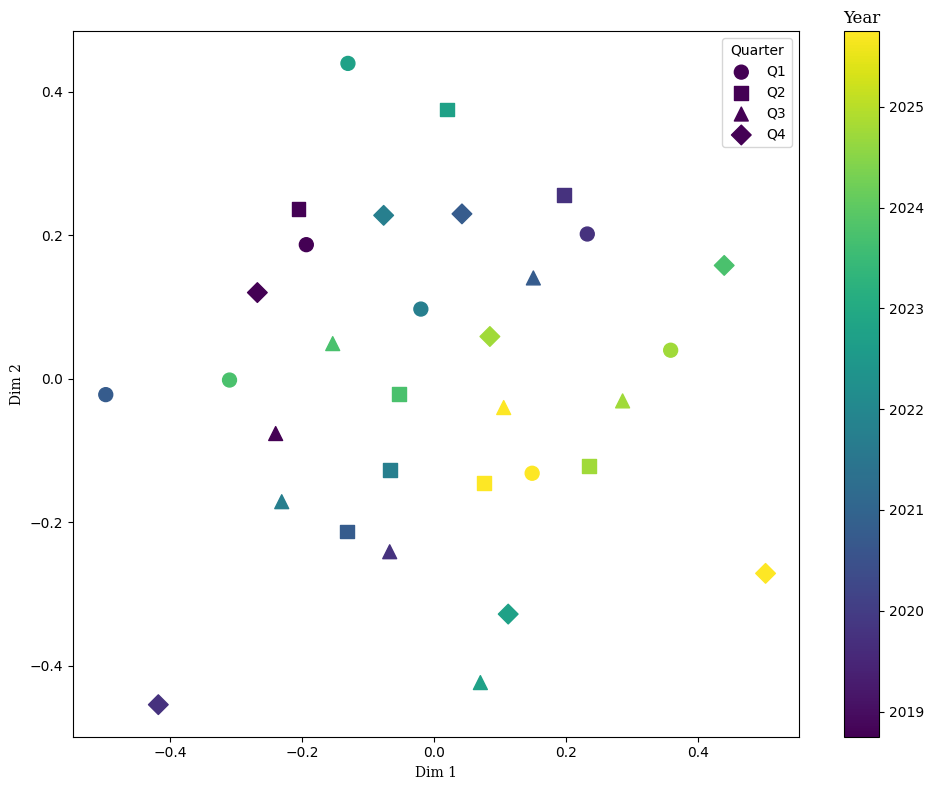

In [38]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10,8))

years = np.array([int(g[:4]) for g in groups])
quarters = np.array([int(g.split('-Q')[1]) for g in groups])
time_continuous = years + (quarters - 1)/4

markers = {1:'o', 2:'s', 3:'^', 4:'D'}

for q in [1,2,3,4]:
    idx = np.where(quarters == q)

    sc = plt.scatter(
        Y_js[idx,0], Y_js[idx,1],
        c=time_continuous[idx],
        cmap='viridis',
        s=100,
        marker=markers[q],
        label=f"Q{q}"
    )

# colorbar on top
cbar = plt.colorbar(sc)
cbar.ax.set_title("Year", fontname="DejaVu Serif")

plt.legend(title="Quarter")

plt.xlabel("Dim 1", fontname="DejaVu Serif")
plt.ylabel("Dim 2", fontname="DejaVu Serif")

plt.tight_layout()
plt.show()

In [39]:
np.savez("JSF_mag.npz", Y=Y_js, groups=groups)

## 3d eme

In [47]:
mds3 = MDS(n_components=3, dissimilarity='precomputed', random_state=seed)
Y3 = mds3.fit_transform(F_js)

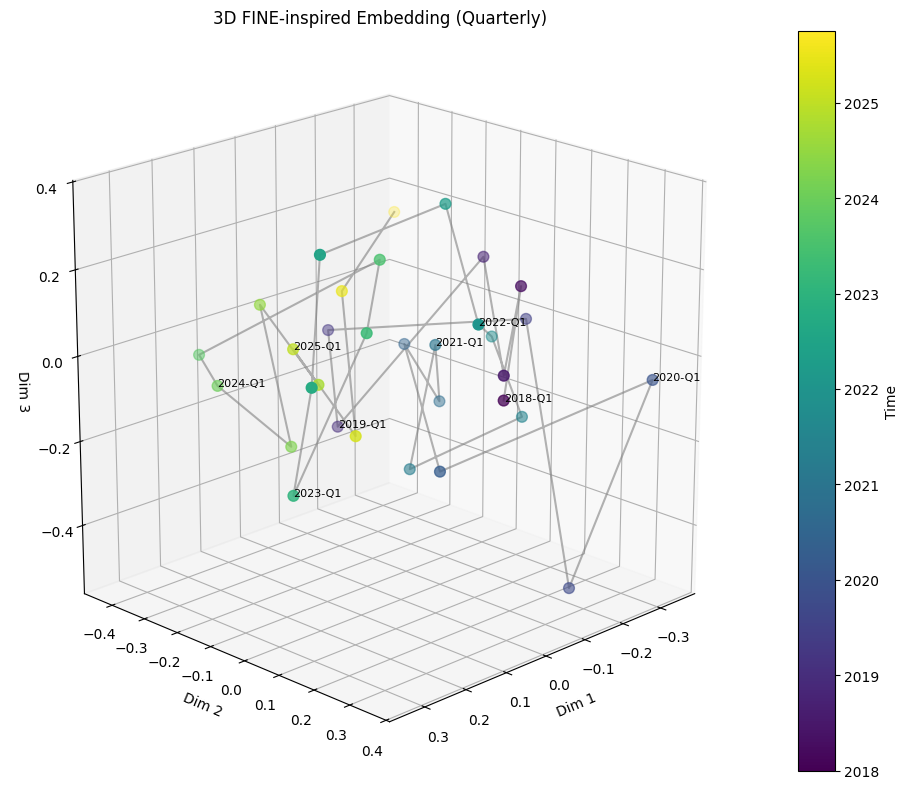

In [48]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(
    Y3[:,0], Y3[:,1], Y3[:,2],
    c=time_continuous,
    cmap='viridis',
    s=60
)

order = np.argsort(time_continuous)

ax.plot(
    Y3[order,0],
    Y3[order,1],
    Y3[order,2],
    color='gray',
    alpha=0.6
)

for i in range(0, len(groups), 4):
    ax.text(
        Y3[i,0], Y3[i,1], Y3[i,2],
        groups[i],
        fontsize=8
    )

ax.view_init(elev=20, azim=45)
ax.set_box_aspect([1,1,1])

ax.set_xlabel("Dim 1")
ax.set_ylabel("Dim 2")
ax.set_zlabel("Dim 3")
ax.set_title("3D FINE-inspired Embedding (Quarterly)")

fig.colorbar(sc, label="Time")

plt.tight_layout()
plt.show()

In [49]:
import plotly.express as px

fig = px.scatter_3d(
    x=Y3[:,0],
    y=Y3[:,1],
    z=Y3[:,2],
    color=time_continuous,
    title="3D Embedding"
)

fig.show()

In [ ]:
print("3D MDS stress:", mds3.stress_)

3D MDS stress: 4.002714275352967


In [50]:
from scipy.spatial.distance import pdist, squareform
import numpy as np

dist_Y3 = squareform(pdist(Y3))

stress3_norm = np.sqrt(
    np.sum((dist_Y3 - F_js)**2) / np.sum(F_js**2)
)

print("Normalized 3D stress:", stress3_norm)

Normalized 3D stress: 0.22852797980541634


### 4D and 5D eme

In [58]:
# 4D MDS
mds4 = MDS(n_components=4, dissimilarity='precomputed', random_state=seed)
Y4 = mds4.fit_transform(F_js)

In [59]:
print("4D MDS stress:", mds4.stress_)

4D MDS stress: 3.7769870681075948


In [54]:
from scipy.spatial.distance import pdist, squareform
import numpy as np

dist_Y4 = squareform(pdist(Y4))

stress4_norm = np.sqrt(
    np.sum((dist_Y4 - F_js)**2) / np.sum(F_js**2)
)

print("Normalized 4D stress:", stress4_norm)

Normalized 4D stress: 0.18114893947091726


In [60]:
# 5D MDS
mds5 = MDS(n_components=5, dissimilarity='precomputed', random_state=seed)
Y5 = mds5.fit_transform(F_js)

In [56]:
print("5D MDS stress:", mds5.stress_)

5D MDS stress: 2.5914819014510004


In [61]:
from scipy.spatial.distance import pdist, squareform
import numpy as np

dist_Y5 = squareform(pdist(Y5))

stress5_norm = np.sqrt(
    np.sum((dist_Y5 - F_js)**2) / np.sum(F_js**2)
)

print("Normalized 5D stress:", stress5_norm)

Normalized 5D stress: 0.14995690299295705


# interpretation / validation

In [62]:
print("raw MDS stress:", mds.stress_)

raw MDS stress: 11.080816828123247


In [64]:
from scipy.spatial.distance import pdist, squareform
import numpy as np

dist_Y = squareform(pdist(Y_js))

stress_norm = np.sqrt(
    np.sum((dist_Y - F_js)**2) / np.sum(F_js**2)
)

print("Normalized stress:", stress_norm)

Normalized stress: 0.3105496581444488


In [66]:
# Distance preservation
from scipy.spatial.distance import pdist, squareform

dist_Y = squareform(pdist(Y_js))
corr_dist = np.corrcoef(dist_Y.flatten(), F_js.flatten())[0,1]

print("Distance preservation:", corr_dist)

Distance preservation: 0.7677772907383749


In [67]:
# intrinsic dimensionality
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca.fit(Y_js)

print(pca.explained_variance_ratio_)

[0.54407377 0.45592623]


## Correlation

In [68]:
from scipy.stats import spearmanr

rho, _ = spearmanr(Y_js[:,0], time_continuous)

print("Spearman (Dim1 vs time):", rho)

Spearman (Dim1 vs time): 0.5623167155425219


In [69]:
from scipy.stats import spearmanr

rho, _ = spearmanr(Y_js[:,1], time_continuous)
print("Spearman (Dim2 vs time):", rho)

Spearman (Dim2 vs time): -0.28958944281524923


# JS interpretation and validation

In [70]:
print(JS.min(), JS.max(), JS.mean())

0.0 0.33780735758015723 0.11212652168853529


In [71]:
from sklearn.manifold import MDS
import numpy as np
import matplotlib.pyplot as plt

# --- 1D MDS ---
mds_1d = MDS(n_components=1, dissimilarity='precomputed', random_state=seed)
Y1 = mds_1d.fit_transform(JS * 1000) #keep scale

# flatten for plotting
Y1 = Y1.ravel()

# align with time
if np.corrcoef(Y1, time_continuous)[0,1] < 0:
    Y1 *= -1

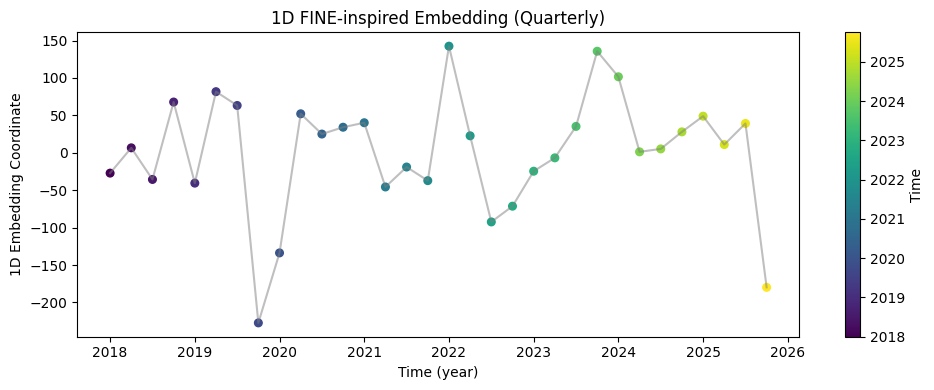

In [72]:
plt.figure(figsize=(10,4))

# x-axis = time ordering
order = np.argsort(time_continuous)

plt.scatter(
    time_continuous[order],
    Y1[order],
    c=time_continuous[order],
    cmap='viridis',
    s=30
)

# optional line to show trajectory
plt.plot(
    time_continuous[order],
    Y1[order],
    color='gray',
    alpha=0.5
)

plt.xlabel("Time (year)")
plt.ylabel("1D Embedding Coordinate")
plt.title("1D FINE-inspired Embedding (Quarterly)")

plt.colorbar(label="Time")
plt.tight_layout()
plt.show()